# Comparison in NATRE region

Goal here is to compare my results in the NATRE region to Ferrari & Polzin results AND to Castro & Brullon results. I want to make a figure analagous to Broullon et al (2026) Fig 2. Start by just making your version in this notebook, then maybe download their data to put everything on one set of axes afterward.

In [62]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw
import rioxarray as rxr #load .tif files

In [3]:
ds_pbar = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_var.nc')

In [4]:
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')
ds_pbar_grad = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grad_cip_masking.nc')

In [5]:
ds_pbar_grid = ds_pbar_grid.assign_coords(LON_left = ds_pbar_grad.LON_left,LAT_left = ds_pbar_grad.LAT_left)
ds_pbar_grid = xr.merge([ds_pbar_grid, ds_pbar_grad.drop_vars({'DENSITY'})])

In [6]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

## Data Selection

In [26]:
region_mask = (
    (ds_pbar.LAT >= 20) & (ds_pbar.LAT <= 31) &
    (ds_pbar.LON >= -38) & (ds_pbar.LON <= -20) &
    (ds_pbar.TIME >= np.datetime64('2014-01-01')) &
    (ds_pbar.TIME <  np.datetime64('2025-01-01'))
)

NATRE_pbar = ds_pbar.where(region_mask, drop=True)

In [27]:
NATRE_pbar

<xarray.Dataset>
Dimensions:        (PROFILE: 8886, PRESSURE_mean: 1001)
Coordinates:
  * PRESSURE_mean  (PRESSURE_mean) int64 0 2 4 6 8 ... 1992 1994 1996 1998 2000
  * PROFILE        (PROFILE) int64 110380 111287 2256939 ... 1638157 1646617
    LAT            (PROFILE) float64 20.0 20.0 20.0 20.0 ... 30.99 31.0 31.0
    LON            (PROFILE) float64 -25.28 -26.68 -37.02 ... -28.91 -28.91
    TIME           (PROFILE) datetime64[ns] 2015-06-05T19:13:00.000000256 ......
Data variables: (12/16)
    CT_sort        (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SA_sort        (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SPICE_sort     (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    DENSITY        (PROFILE, PRESSURE_mean) float64 nan 24.83 24.85 ... nan nan
    CT_sort_m      (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SA_sort_m      (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    ...             ...
    CT_e_var       (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SA_e_var       (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SPICE_e_var    (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    CT_m_var       (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SA_m_var       (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan
    SPICE_m_var    (PROFILE, PRESSURE_mean) float64 nan nan nan ... nan nan nan

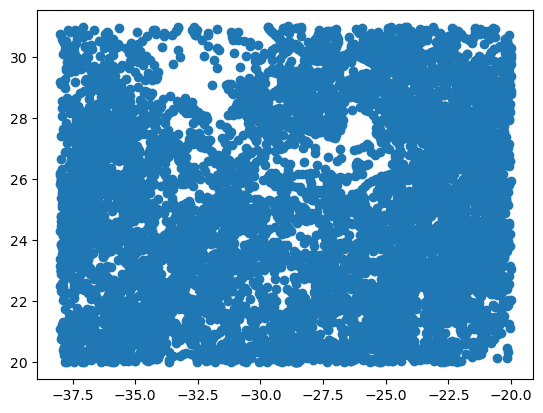

In [28]:
plt.scatter(NATRE_pbar.LON, NATRE_pbar.LAT)

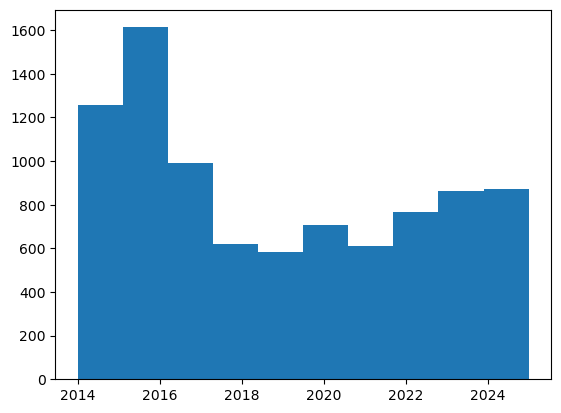

In [29]:
plt.hist(NATRE_pbar.TIME, bins=10);

In [25]:
NATRE_K_rho = K_rho_p.sel(
    LAT=slice(20, 31),
    LON=slice(-38, -20)
)

Text(0.5, 1.0, 'Grid points in NATRE region')

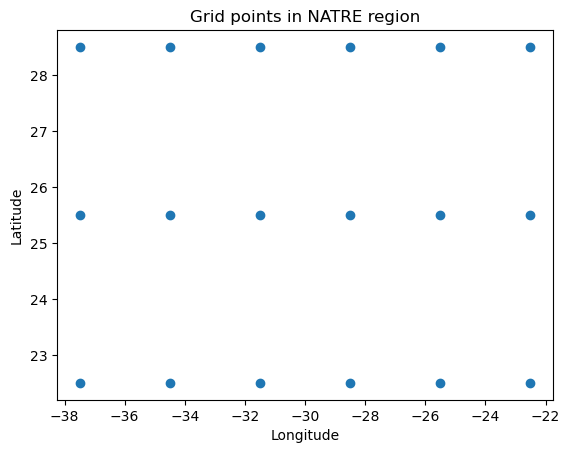

In [35]:
lon2d, lat2d = np.meshgrid(NATRE_K_rho.LON, NATRE_K_rho.LAT)

plt.scatter(lon2d, lat2d)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Grid points in NATRE region")

## Calculate mean profiles

In [46]:
K_mean = NATRE_K_rho.mean(['LON','LAT'])

P_perp_CT = K_mean * NATRE_pbar.CT_m_var.mean('PROFILE')
P_para_CT = K_mean * NATRE_pbar.CT_e_var.mean('PROFILE')

P_perp_SA = K_mean * NATRE_pbar.SA_m_var.mean('PROFILE')
P_para_SA = K_mean * NATRE_pbar.SA_e_var.mean('PROFILE')

In [71]:
FP_K_rho = pd.read_csv('CB_Fig2/FP_K_rho.csv', header=None)
CB_K_rho = pd.read_csv('CB_Fig2/CB_K_rho.csv', header=None)

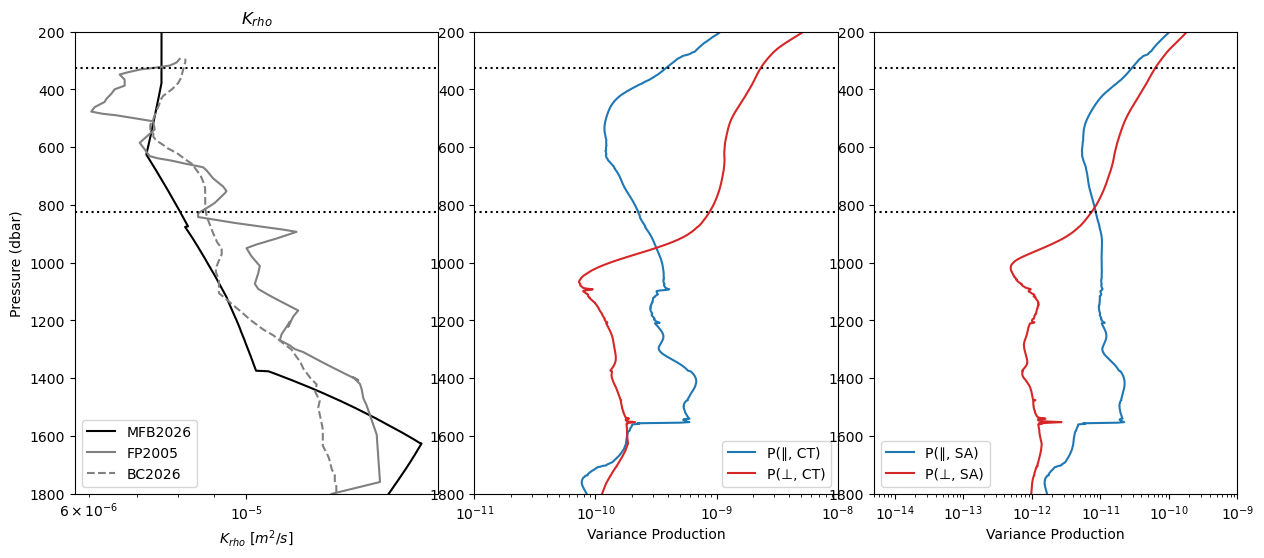

In [75]:
plt.figure(figsize=(15,6))

plt.subplot(131)
K_mean.plot(y='PRESSURE_mean', color='k', label='MFB2026')
plt.plot(FP_K_rho[0], FP_K_rho[1], color='gray', label='FP2005')
plt.plot(CB_K_rho[0], CB_K_rho[1], color='gray', linestyle='--', label='BC2026')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('Pressure (dbar)')
plt.ylim(1800,200)
plt.xscale('log')
plt.xlabel('$K_{rho}$ [$m^2/s$]')
plt.title('$K_{rho}$')

plt.subplot(132)
P_para_CT.plot(y='PRESSURE_mean', label='P(∥, CT)', color='tab:blue')
P_perp_CT.plot(y='PRESSURE_mean', label='P(⊥, CT)', color='tab:red')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('')
#plt.gca().set_yticklabels([])
plt.ylim(1800,200)
plt.xscale('log')
plt.xlim(1e-11, 1e-8)
plt.xlabel('Variance Production')
plt.title('')

plt.subplot(133)
P_para_SA.plot(y='PRESSURE_mean', label='P(∥, SA)', color='tab:blue')
P_perp_SA.plot(y='PRESSURE_mean', label='P(⊥, SA)', color='tab:red')
plt.axhline(325, color='k', linestyle=':')
plt.axhline(825, color='k', linestyle=':')
plt.legend()
plt.ylabel('')
#plt.gca().set_yticklabels([])
plt.ylim(1800,200)
plt.xscale('log')
plt.xlim(5e-15, 1e-9)
plt.xlabel('Variance Production')
plt.title('')

plt.subplots_adjust(wspace=0.1)